# iMem — Semantic Image Search POC #2 (Server / Container Qdrant)

This notebook mirrors `00-poc-personal-imgs.ipynb` but targets a **Qdrant server running in a container**
(see `docker-compose.yml` at the repo root) instead of local/embedded mode, and indexes the
test datasets (Olivetti Faces + Caltech-101) via `src.dataloader` instead of custom images.

Before running this notebook, start the Qdrant container:
```bash
docker compose up -d
```

Steps:
1. Load SigLIP2 model on Apple Silicon
2. Load Olivetti Faces + Caltech-101 test datasets (auto-downloaded/cached under `data/`)
3. Encode images into embeddings
4. Store embeddings in Qdrant (server mode, `localhost:6333`)
5. Text-to-image search
6. Image-to-image search


## Setup and Imports

In [18]:
import sys
sys.path.append('..')

import torch
import numpy as np
from transformers import AutoModel, AutoProcessor
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import uuid
import warnings
warnings.filterwarnings('ignore')

from src.dataloader import load_olivetti_faces, load_caltech101, load_all_test_data

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'MPS available: {torch.backends.mps.is_available()}')


PyTorch version: 2.12.1
CUDA available: False
MPS available: True


## Device Setup

In [19]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using Apple Silicon (MPS)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using NVIDIA GPU')
else:
    device = torch.device('cpu')
    print('Using CPU (slower)')

print(f'Device: {device}')


Using Apple Silicon (MPS)
Device: mps


## Load Model and Processor

In [20]:
MODEL_ID = 'google/siglip2-base-patch16-224'
EMBEDDING_DIM = 768
BATCH_SIZE = 16

print(f'Loading model: {MODEL_ID}')
model = AutoModel.from_pretrained(MODEL_ID).to(device).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID)

print(f'Model loaded. Embedding dimension: {EMBEDDING_DIM}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M')


Loading model: google/siglip2-base-patch16-224


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 408/408 [00:00<00:00, 9131.38it/s]


Model loaded. Embedding dimension: 768
Total parameters: 375.2M


## Helper Functions

In [21]:
def encode_images(image_paths, batch_size=BATCH_SIZE, device=device):
    embeddings = []
    valid_paths_all = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc='Encoding images'):
        batch_paths = image_paths[i : i + batch_size]

        images = []
        valid_paths = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert('RGB')
                images.append(img)
                valid_paths.append(path)
            except Exception as e:
                print(f'Failed to load {path}: {e}')

        if not images:
            continue

        inputs = processor(images=images, return_tensors='pt', padding=True).to(device)
        with torch.no_grad():
            outputs = model.get_image_features(**inputs)

        img_emb = outputs.pooler_output
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        embeddings.append(img_emb.cpu().numpy())
        valid_paths_all.extend(valid_paths)

    if not embeddings:
        return np.array([]), []

    return np.vstack(embeddings), valid_paths_all


def encode_text(texts, device=device):
    inputs = processor(text=texts, padding='max_length', return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model.get_text_features(**inputs)
    text_emb = outputs.pooler_output
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    return text_emb.cpu().numpy()


print('Helper functions defined.')


Helper functions defined.


## Setup Qdrant (server / container mode)

Assumes the container from `docker-compose.yml` is running and reachable at `localhost:6333`.
Unlike `01-poc.ipynb` (embedded/local-mode `QdrantClient(path=...)`), this connects over HTTP
to a real Qdrant server — the same client API you'd use against a remote/production instance.

In [22]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct, Filter, FieldCondition, MatchValue

COLLECTION_NAME = 'images_siglip2_base_v2'
QDRANT_HOST = 'localhost'
QDRANT_PORT = 6333

client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)

collections = client.get_collections().collections
collection_names = [c.name for c in collections]

if COLLECTION_NAME in collection_names:
    client.delete_collection(COLLECTION_NAME)

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE),
)
print(f'Qdrant collection created: {COLLECTION_NAME}')


Qdrant collection created: images_siglip2_base_v2


## Load Test Datasets

In [23]:
records = load_all_test_data()
image_paths = [str(r.path) for r in records]

print(f"Found {len(image_paths)} images ("
      f"{sum(1 for r in records if r.dataset == 'olivetti')} Olivetti, "
      f"{sum(1 for r in records if r.dataset == 'caltech101')} Caltech-101)")


Indexing Caltech-101 images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9144/9144 [00:00<00:00, 269886.18it/s]

Found 9544 images (400 Olivetti, 9144 Caltech-101)


## Index Images

In [28]:
def image_exists(path):
    hits, _ = client.scroll(
        collection_name=COLLECTION_NAME,
        scroll_filter=Filter(
            must=[FieldCondition(key="path", match=MatchValue(value=path))]
        ),
        limit=100,
        with_payload=True,
        with_vectors=False,
    )
    return len(hits) > 0


new_image_paths = [p for p in image_paths if not image_exists(p)]
print(f"New images: {len(new_image_paths)}")


New images: 0


In [29]:
def normalize_path(path):
    return str(Path(path).resolve())


def point_id_from_path(path):
    """
    Stable Qdrant point id based on file path.
    Qdrant accepts UUID strings as point ids.
    """
    normalized = normalize_path(path)
    return str(uuid.uuid5(uuid.NAMESPACE_URL, normalized))


def encode_image_batch(batch_paths, device=device):
    images = []
    valid_paths = []

    for path in batch_paths:
        try:
            img = Image.open(path).convert("RGB")
            images.append(img)
            valid_paths.append(path)
        except Exception as e:
            tqdm.write(f"Failed to load {path}: {e}")

    if not images:
        return np.array([]), []

    inputs = processor(
        images=images,
        return_tensors="pt",
        padding=True,
    ).to(device)

    with torch.no_grad():
        outputs = model.get_image_features(**inputs)

    if hasattr(outputs, "pooler_output"):
        img_emb = outputs.pooler_output
    else:
        img_emb = outputs

    img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)

    return img_emb.cpu().numpy(), valid_paths


def index_images_batched(image_paths, index_batch_size=BATCH_SIZE):
    total_indexed = 0

    if len(image_paths) == 0:
        print("Nothing new to index.")
        return 0

    with tqdm(total=len(image_paths), desc="Indexing images", unit="img") as pbar:
        for start in range(0, len(image_paths), index_batch_size):
            batch_paths = image_paths[start : start + index_batch_size]

            embeddings, valid_paths = encode_image_batch(batch_paths)

            if len(valid_paths) > 0:
                points = [
                    PointStruct(
                        id=point_id_from_path(path),
                        vector=embedding.tolist(),
                        payload={
                            "path": normalize_path(path),
                            "filename": Path(path).name,
                        },
                    )
                    for embedding, path in zip(embeddings, valid_paths)
                ]

                client.upsert(
                    collection_name=COLLECTION_NAME,
                    points=points,
                )

                total_indexed += len(points)

            pbar.update(len(batch_paths))
            pbar.set_postfix(indexed=total_indexed)

    print(f"Indexed total: {total_indexed} images")
    return total_indexed

In [30]:
index_images_batched(new_image_paths)

Nothing new to index.


0

In [31]:
def show_results(results, cols=3, figsize_per_image=4):
    import matplotlib.pyplot as plt

    points = results.points
    n = len(points)

    if n == 0:
        print("No results")
        return

    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * figsize_per_image, rows * figsize_per_image))

    for i, hit in enumerate(points):
        img_path = hit.payload["path"]
        score = hit.score
        img = Image.open(img_path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"#{i + 1} | score: {score:.4f}", fontsize=10)

    plt.tight_layout()
    plt.show()


## Text-to-Image Search

Query: a person's face
1. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_008.png (score: 0.1563)
2. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_22/sample_225.png (score: 0.1547)
3. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_09/sample_099.png (score: 0.1537)
4. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_03/sample_036.png (score: 0.1531)
5. /Users/evpc/Documents/self_edu/imem/data/olivetti/person_03/sample_035.png (score: 0.1525)


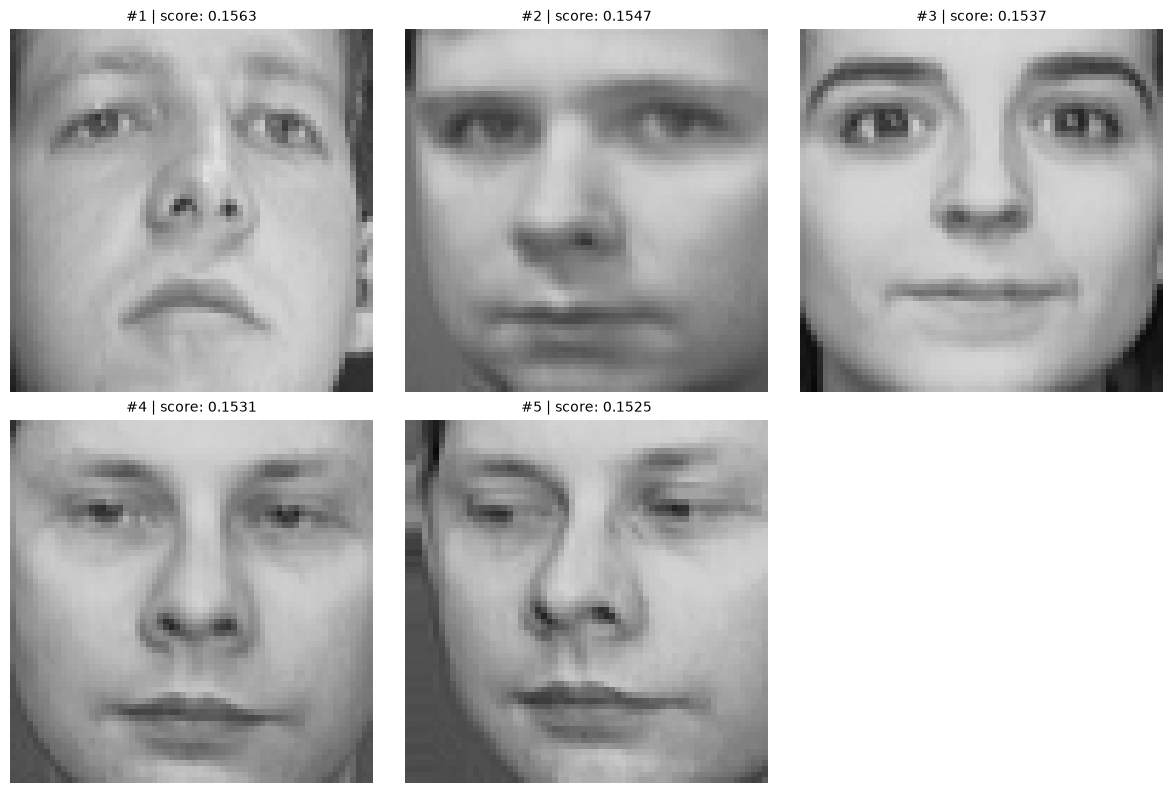

In [32]:
def search_by_text(query, top_k=5):
    query_emb = encode_text([query])[0]
    results = client.query_points(collection_name=COLLECTION_NAME, query=query_emb.tolist(), limit=top_k)
    print(f'Query: {query}')
    for rank, hit in enumerate(results.points, 1):
        print(f'{rank}. {hit.payload["path"]} (score: {hit.score:.4f})')
    return results


results = search_by_text("a person's face")
show_results(results, cols=3)


Query: an airplane
1. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0666.jpg (score: 0.1386)
2. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0789.jpg (score: 0.1379)
3. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0387.jpg (score: 0.1368)
4. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0610.jpg (score: 0.1357)
5. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/airplanes/image_0687.jpg (score: 0.1356)


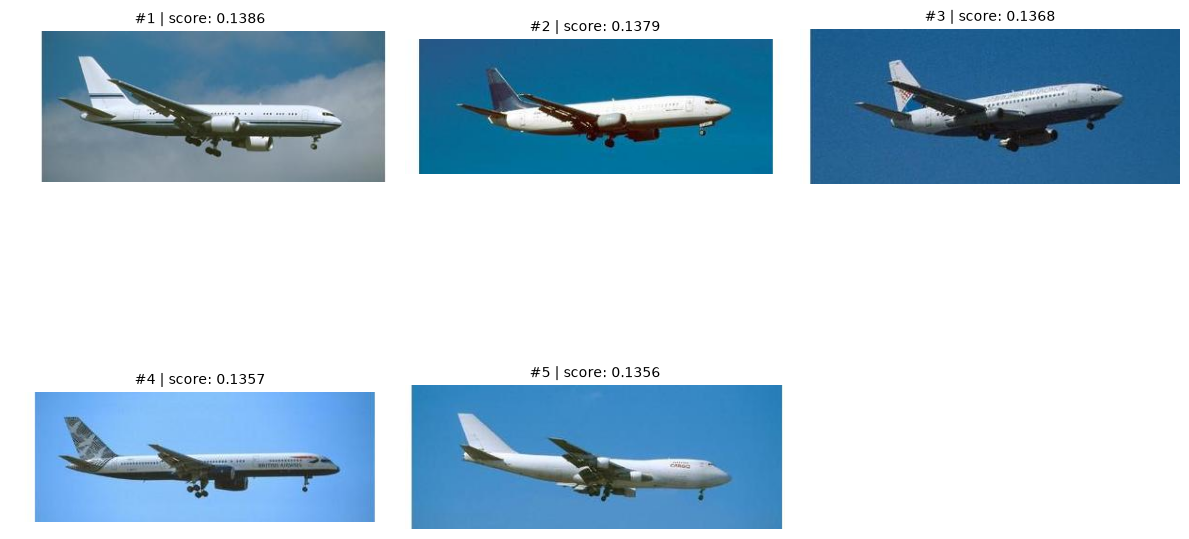

In [33]:
results = search_by_text("an airplane")
show_results(results, cols=3)


## Image-to-Image Search

In [34]:
image_paths 

['/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_000.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_001.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_002.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_003.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_004.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_005.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_006.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_007.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_008.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_00/sample_009.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_01/sample_010.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/person_01/sample_011.png',
 '/Users/evpc/Documents/self_edu/imem/data/olivetti/

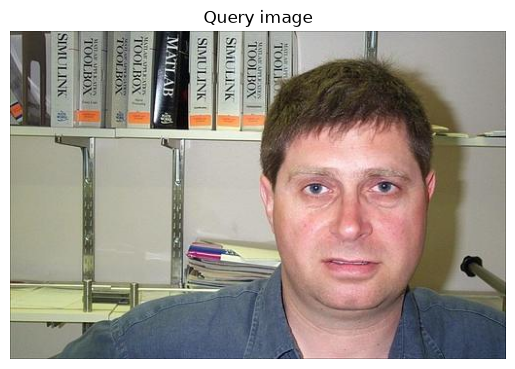

Query image: /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces/image_0001.jpg
1. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces/image_0001.jpg (score: 1.0000)
2. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces/image_0019.jpg (score: 0.9563)
3. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces/image_0002.jpg (score: 0.9562)
4. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces_easy/image_0001.jpg (score: 0.9458)
5. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces/image_0020.jpg (score: 0.9443)
6. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces/image_0005.jpg (score: 0.9409)
7. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/101_ObjectCategories/Faces_easy/image_0002.jpg (score: 0.9355)
8. /Users/evpc/Documents/self_edu/imem/data/raw/caltech101/1

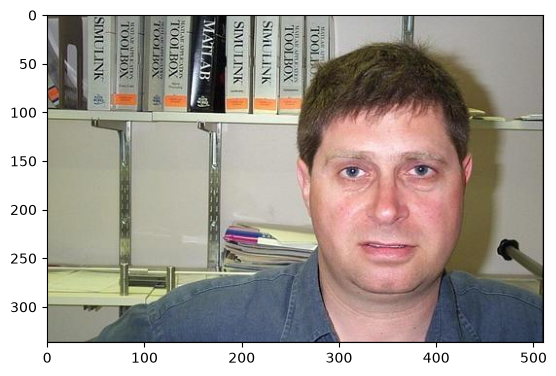

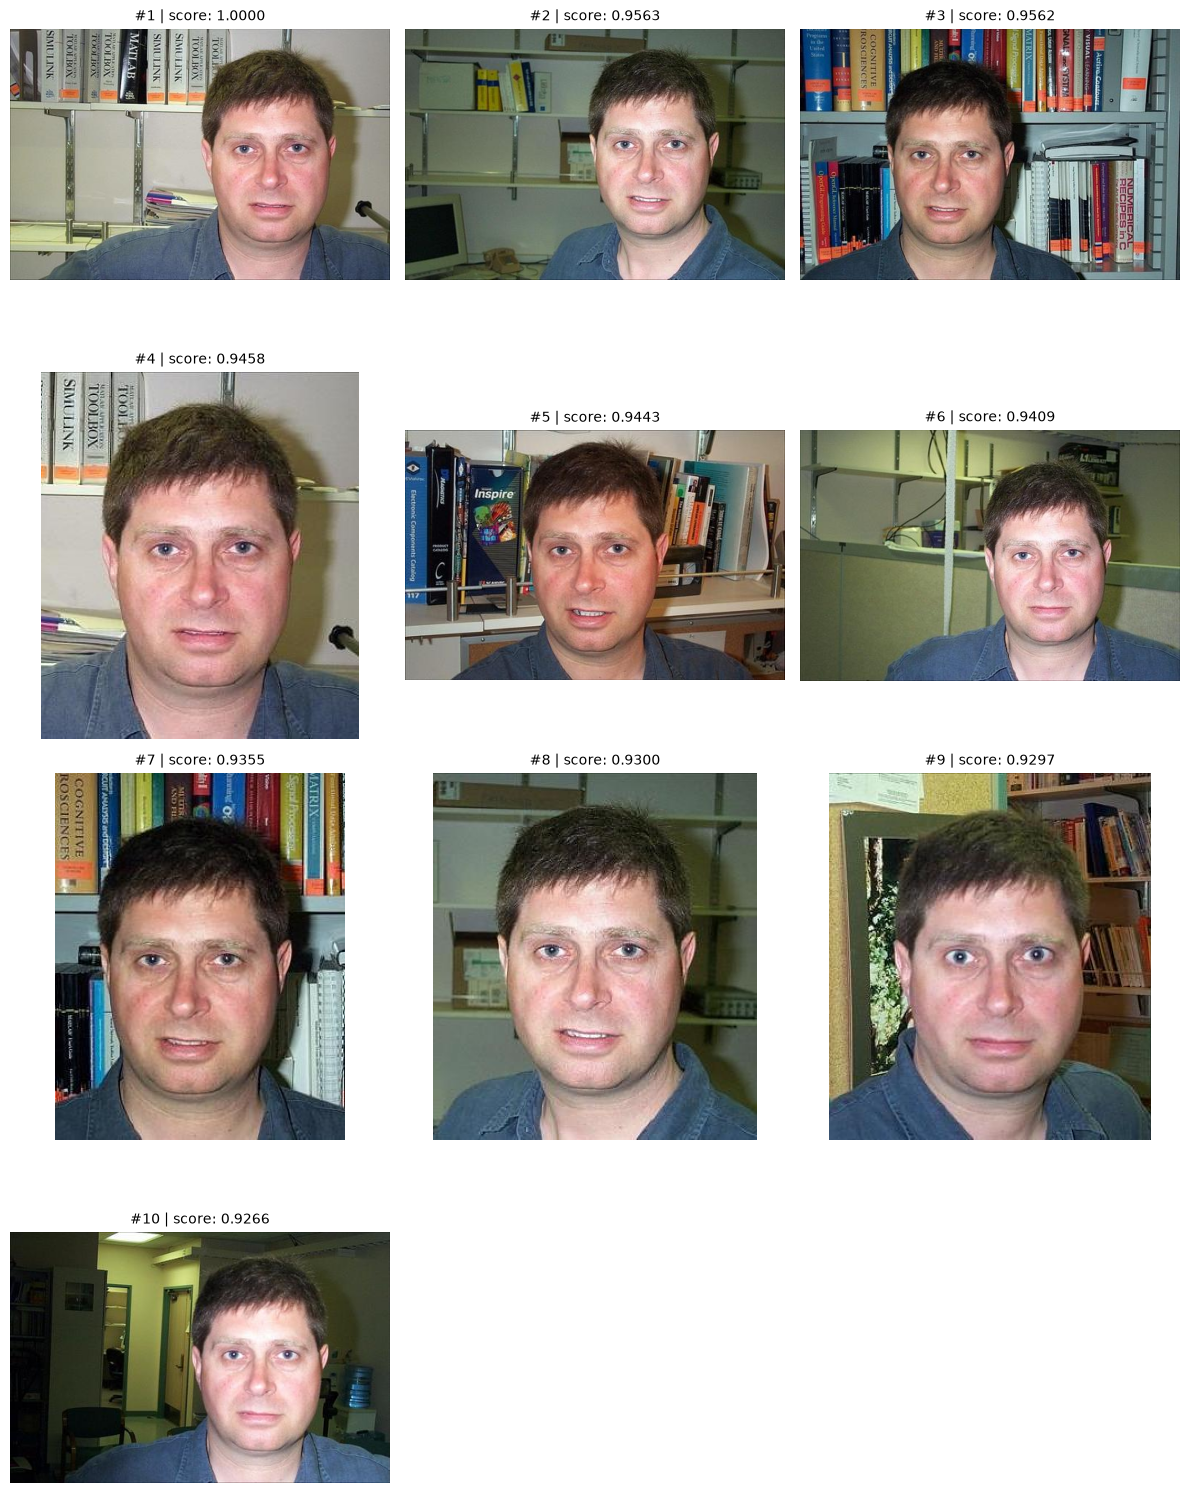

In [42]:
def search_by_image(image_path, top_k=5):
    query_img = Image.open(image_path).convert("RGB")

    inputs = processor(images=[query_img], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = model.get_image_features(**inputs)

    query_emb = outputs.pooler_output
    query_emb = query_emb / query_emb.norm(dim=-1, keepdim=True)
    query_emb = query_emb[0].cpu().numpy()

    results = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_emb.tolist(),
        limit=top_k,
        with_payload=True,
    )

    print(f"Query image: {image_path}")
    for rank, hit in enumerate(results.points, 1):
        print(f'{rank}. {hit.payload["path"]} (score: {hit.score:.4f})')

    return results


# Use one of the indexed images itself as a query, e.g. an Olivetti face
k_faces = 10 # 10 Images per face in Olivetti ds
face_image_paths = [img_path for img_path in image_paths if "faces" in img_path.lower()]
query_image_path = face_image_paths[0]
img = Image.open(query_image_path).convert("RGB")

import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis("off")
plt.title("Query image")
plt.show()

results = search_by_image(query_image_path, top_k=10) # top_k = 10 -> 10 images per face
plt.imshow(Image.open(query_image_path))
plt.show()
show_results(results, cols=3)
